# 1-D Exploratory Data Analysis

In this notebook, do some EDA in one dimension. Pick a column  (or a set of columns) you're interested in looking at. Calculate some summary statistics (like mean,median,min,max,sd). Then, make some plots to visualize the distribution of the data. Distirbution plots include things like histograms, boxplots, dotplots, beeswarms, and violin plots. Review [ggplot-intro](https://github.com/data4news/ggplot-intro) for examples of these kinds of distribution plots.

### Standard Python and R imports

In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [3]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [2]:
%%R

# My commonly used R imports

require('tidyverse')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Lade nötiges Paket: tidyverse


## Load the data

In [4]:
%%R
 
# Import data with R
df <- read_csv('park.csv', show_col_types = FALSE)
df %>% head(4)

# A tibble: 4 × 5
   Year `OPRHP Region` County      Facility                Attendance
  <dbl> <chr>          <chr>       <chr>                        <dbl>
1  2024 Allegany       Cattaraugus Allegany Quaker Area        807401
2  2024 Allegany       Cattaraugus Allegany Red House Area     718294
3  2024 Allegany       Chautauqua  Barcelona Lighthouse          9082
4  2024 Allegany       Chautauqua  Lake Erie St Pk              90188


In [19]:
%%R
data <- df %>% 
  mutate(Attendance = Attendance / 1000)

  data

# A tibble: 5,253 × 5
    Year `OPRHP Region` County          Facility                Attendance
   <dbl> <chr>          <chr>           <chr>                        <dbl>
 1  2024 Allegany       Cattaraugus     Allegany Quaker Area        807.  
 2  2024 Allegany       Cattaraugus     Allegany Red House Area     718.  
 3  2024 Allegany       Chautauqua      Barcelona Lighthouse          9.08
 4  2024 Allegany       Chautauqua      Lake Erie St Pk              90.2 
 5  2024 Allegany       Chautauqua      Long Point Marina           152.  
 6  2024 Allegany       Chautauqua      Midway State Park           116.  
 7  2024 Allegany       Chautauqua      Sunset Bay MarinePark        35.1 
 8  2024 Central        Broome          Chenango Valley St Pk       300.  
 9  2024 Central        Broome/Delaware Oquaga State Park            71.4 
10  2024 Central        Chenango        Bowman Lake St Pk            72.2 
# ℹ 5,243 more rows
# ℹ Use `print(n = ...)` to see more rows


## only keep data since 2015

In [22]:
%%R
data <- data %>%
  filter(Year >= 2015)

data

# A tibble: 2,421 × 5
    Year `OPRHP Region` County          Facility                Attendance
   <dbl> <chr>          <chr>           <chr>                        <dbl>
 1  2024 Allegany       Cattaraugus     Allegany Quaker Area        807.  
 2  2024 Allegany       Cattaraugus     Allegany Red House Area     718.  
 3  2024 Allegany       Chautauqua      Barcelona Lighthouse          9.08
 4  2024 Allegany       Chautauqua      Lake Erie St Pk              90.2 
 5  2024 Allegany       Chautauqua      Long Point Marina           152.  
 6  2024 Allegany       Chautauqua      Midway State Park           116.  
 7  2024 Allegany       Chautauqua      Sunset Bay MarinePark        35.1 
 8  2024 Central        Broome          Chenango Valley St Pk       300.  
 9  2024 Central        Broome/Delaware Oquaga State Park            71.4 
10  2024 Central        Chenango        Bowman Lake St Pk            72.2 
# ℹ 2,411 more rows
# ℹ Use `print(n = ...)` to see more rows


In [91]:
%%R

NYC <- data %>% 
filter(`OPRHP Region` == 'New York City') 

Central <- data %>% 
filter(`OPRHP Region` == 'Central') 

NYC %>%
print(n=20)

# A tibble: 101 × 5
    Year `OPRHP Region` County   Facility                             Attendance
   <dbl> <chr>          <chr>    <chr>                                     <dbl>
 1  2024 New York City  Bronx    Roberto Clemente                          457. 
 2  2024 New York City  Kings    Empire Fulton Ferry                         0  
 3  2024 New York City  Kings    Marsha P. Johnston State Park            1191. 
 4  2024 New York City  Kings    Shirley Chisholm State Park               254. 
 5  2024 New York City  New York Franklin D. Roosevelt Four Freedoms…      323. 
 6  2024 New York City  New York Riverbank Fitness Cntr                     26.5
 7  2024 New York City  New York Riverbank Rollr-Ice Rnks                  407. 
 8  2024 New York City  New York Riverbank State Park                     3817. 
 9  2024 New York City  Queens   Bayswater Point St Pk                      16.8
10  2024 New York City  Queens   Gantry Plaza                             3005. 
11  2024

## Summary statistics

Pick a column or set of columns and calculate some summary statistics (like mean,median,min,max,sd).
Hint, you may want to use `group_by` and `summarize`.



In [34]:
%%R 

attendance_stats <- NYC %>%
  group_by(Facility) %>%
  summarize(
    mean_attendance = mean(Attendance, na.rm = TRUE),
    median_attendance = median(Attendance, na.rm = TRUE),
    min_attendance = min(Attendance, na.rm = TRUE),
    max_attendance = max(Attendance, na.rm = TRUE),
    sd_attendance = sd(Attendance, na.rm = TRUE)
  )

attendance_stats


# A tibble: 13 × 6
   Facility      mean_attendance median_attendance min_attendance max_attendance
   <chr>                   <dbl>             <dbl>          <dbl>          <dbl>
 1 Bayswater Po…            15.8              15.6          11.9            20.4
 2 Clay Pit Pon…            38.4              43.7          23.5            47.4
 3 Empire Fulto…             0                 0             0               0  
 4 Franklin D. …           224.              220.          136.            323. 
 5 Gantry Plaza           1627.             1347.         1004.           3005. 
 6 Marsha P Joh…           648.              648.          648.            648. 
 7 Marsha P. Jo…          1388.             1515.          631.           1640. 
 8 Marsha P. Jo…           972.             1191.          469.           1255. 
 9 Riverbank Fi…            17.0              18.2           4.53           26.5
10 Riverbank Ro…           340.              398.           81.1           449. 
11 Riverb

## 1-D visualizations (aka distributions)


### Continus variables

For each continuous variable you are interested in, use ggplot to make a plot of the distribution. You can use histograms, dot plots, box plots, beeswarms, etc...(whichever chart type you found most useful). Learn about that variable and give each chart a headline that explains what you're seeing. The chart can also show the mean or median of the variable for reference (for example for a histogram you can add a vertical line through the median).

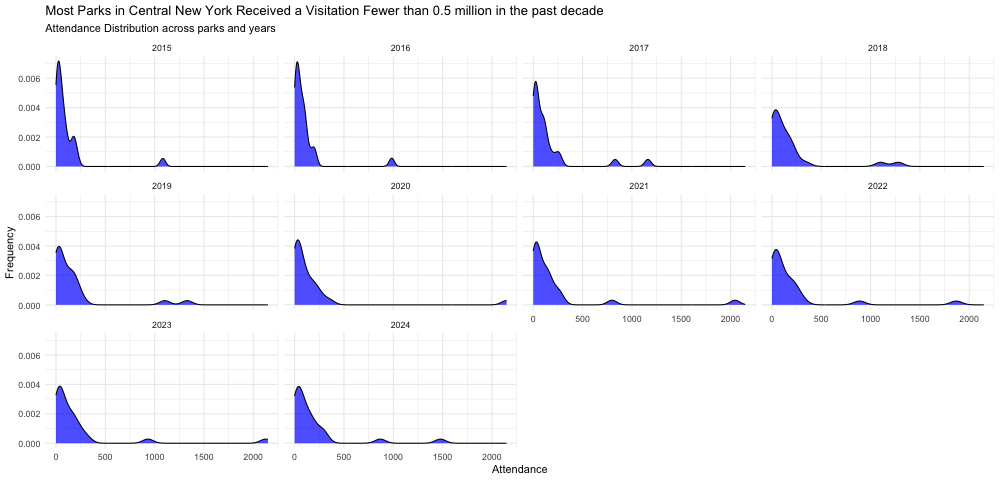

In [103]:
%%R -w 1000

ggplot(Central, aes(x = Attendance)) +
  geom_density( fill = "blue", color = "black", alpha = 0.7) +
  facet_wrap(~Year) +
  labs(title = "Most Parks in Central New York Received a Visitation Fewer than 0.5 million in the past decade",
  subtitle = 'Attendance Distribution across parks and years',
       x = "Attendance",
       y = "Frequency") +
  theme_minimal()

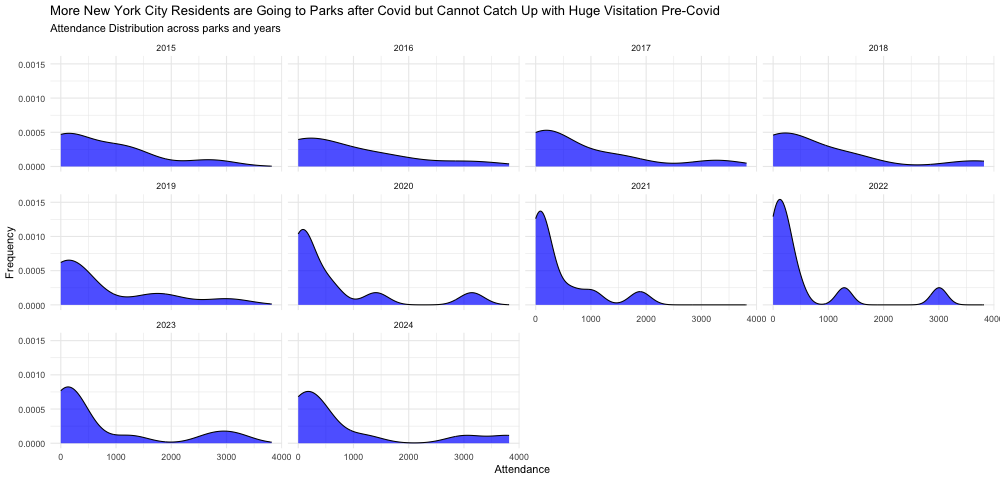

In [102]:
%%R -w 1000

ggplot(NYC, aes(x = Attendance)) +
  geom_density( fill = "blue", color = "black", alpha = 0.7) +
  facet_wrap(~Year) +
  labs(title = "More New York City Residents are Going to Parks after Covid but Cannot Catch Up with Huge Visitation Pre-Covid",
  subtitle = 'Attendance Distribution across parks and years',
       x = "Attendance",
       y = "Frequency") +
  theme_minimal()

### Discrete Variables

If there are any discrete variables you'd like to analyze, you can do that with charts here.

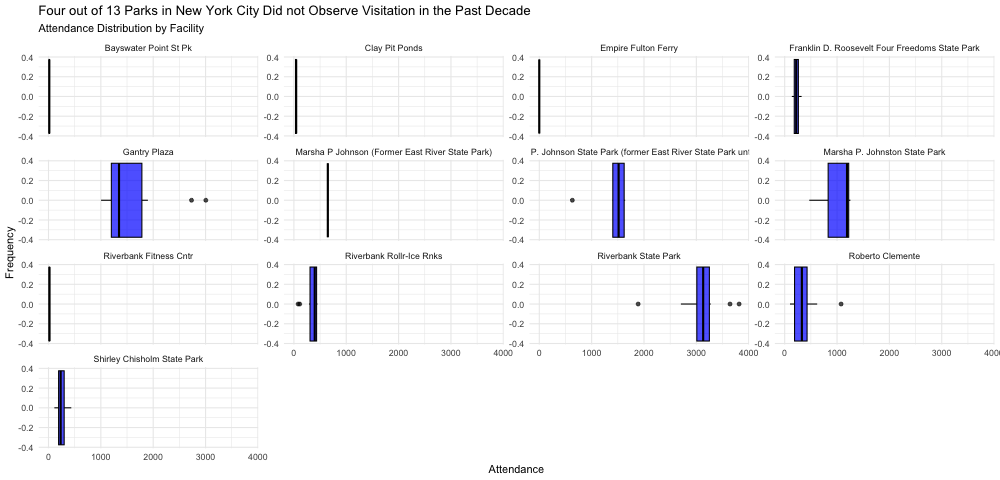

In [107]:
%%R -w 1000
ggplot(NYC, aes(x = Attendance)) +
  geom_boxplot(fill = "blue", color = "black", alpha = 0.7) +
  facet_wrap(~ Facility, scales = "free_y") + 
  labs(title = "Four out of 13 Parks in New York City Did not Observe Visitation in the Past Decade",
       subtitle = 'Attendance Distribution by Facility',
       x = "Attendance",
       y = "Frequency") +
  theme_minimal()


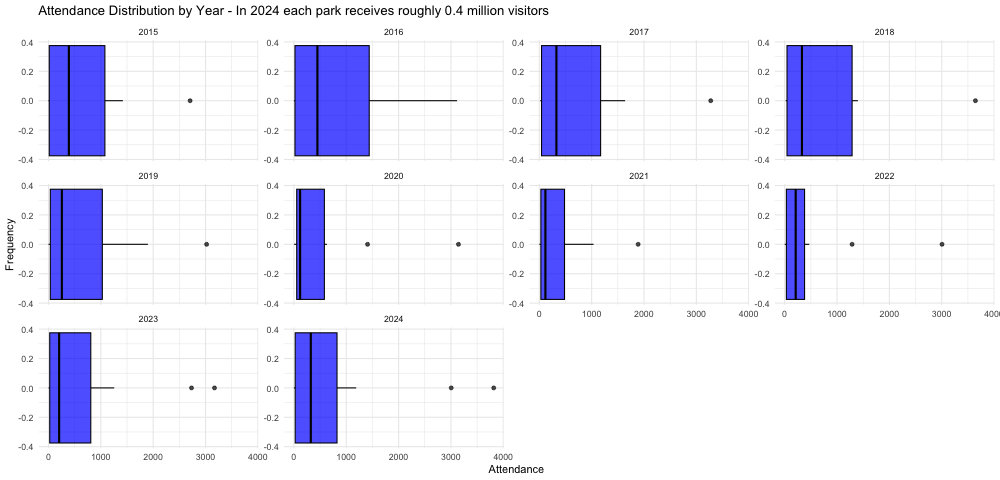

In [64]:
%%R -w 1000
ggplot(NYC, aes(x = Attendance)) +
  geom_boxplot(fill = "blue", color = "black", alpha = 0.7) +
  facet_wrap(~ Year, scales = "free_y") + 
  labs(title = "NYC Parks Broke the Visitation Record by Observing a Visitation by Almost 4 millions",
  subtitle = "Attendance Distribution by Year",
       x = "Attendance",
       y = "Frequency") +
  theme_minimal()

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


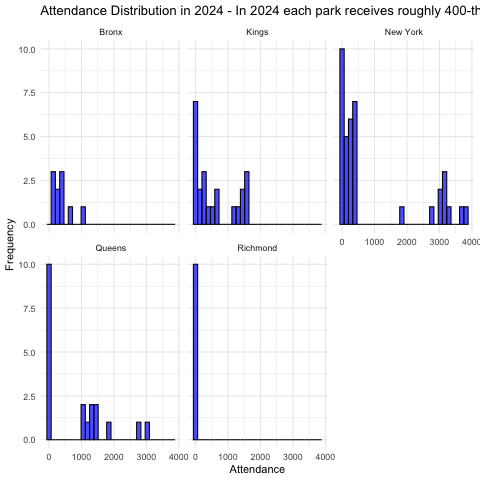

In [73]:
%%R 
ggplot(NYC, aes(x = Attendance)) +
  geom_histogram(fill = "blue", color = "black", alpha = 0.7) +
  facet_wrap(~County) +
  labs(title = "New York Receives the Most Park Visitation in the Past Decade",
  subtitle = "Attendance Distribution by Borough"
       x = "Attendance",
       y = "Frequency") +
  theme_minimal()